In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
import nltk

In [2]:
import sys
print(sys.executable)

c:\Users\justPrapti\anaconda3\envs\machine_learning\python.exe


In [3]:
%pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [4]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\justPrapti\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\justPrapti\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\justPrapti\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [5]:
df = pd.read_csv("Resume.csv")

In [6]:
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [7]:
df.shape

(2484, 4)

In [8]:
df.columns

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='str')

In [9]:
df.isnull().sum()

ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

In [10]:
df['Category'].value_counts()

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

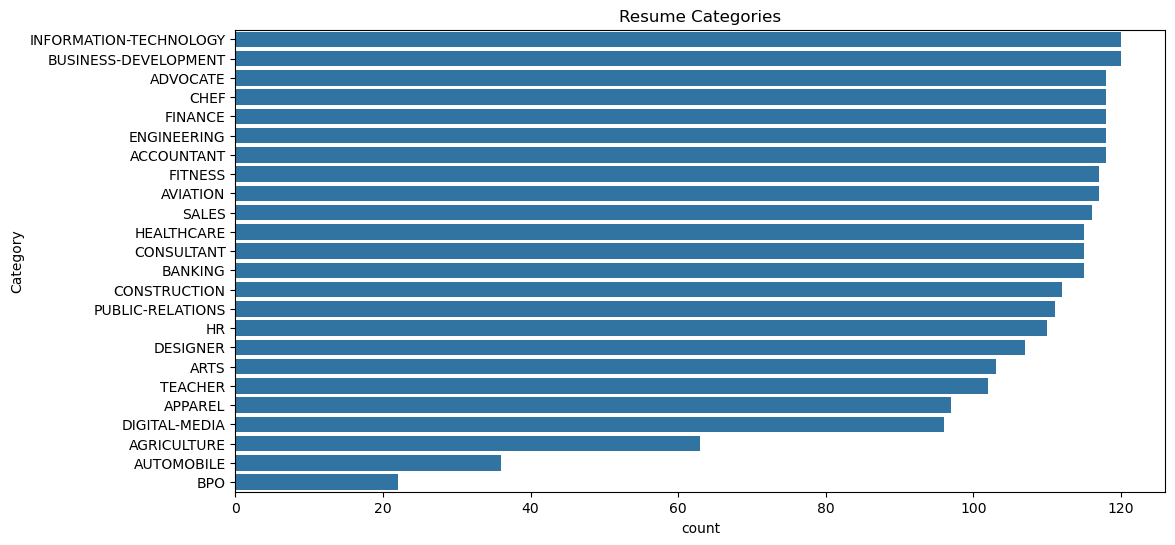

In [11]:
plt.figure(figsize=(12,6))

sns.countplot(y=df['Category'], order= df['Category'].value_counts().index)

plt.title("Resume Categories")
plt.show()

Data cleaning (remove unecessary words for the model)

The ML model doesn't need:

Email IDs
Phone numbers
URLs
Punctuation
Extra spaces

It mainly needs the words that describe the candidate.

In [12]:
from nltk.corpus import stopwords

In [13]:
stop_words=set(stopwords.words("english"))

In [14]:
import re

def clean_resume(text):
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Remove emails
    text = re.sub(r'\S+@\S+', ' ', text)

    # Remove punctuation only
    text = re.sub(r'[^\w\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [15]:
df['Clean_Resume']=df['Resume_str'].apply(clean_resume)

In [16]:
df

,ID,Resume_str,Resume_html,Category,Clean_Resume
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr administrator marketing associate hr admini...
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR,hr specialist us hr operations summary versati...
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr director summary over 20 years experience i...
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr specialist summary dedicated driven and dyn...
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr manager skill highlights hr skills hr depar...
...,...,...,...,...,...
2479,99416532,RANK: SGT/E-5 NON- COMMISSIONED OFFIC...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION,rank sgt e 5 non commissioned officer in charg...
2480,24589765,"GOVERNMENT RELATIONS, COMMUNICATIONS ...","<div class=""fontsize fontface vmargins hmargin...",AVIATION,government relations communications and organi...
2481,31605080,GEEK SQUAD AGENT Professional...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION,geek squad agent professional profile it suppo...
2482,21190805,PROGRAM DIRECTOR / OFFICE MANAGER ...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION,program director office manager summary highly...


In [17]:
print("Original Resume:\n")
print(df['Resume_str'][0])

print("\n" + "="*80 + "\n")

print("Cleaned Resume:\n")
print(df['Clean_Resume'][0])

Original Resume:

         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ  ,   Micros    Opera PMS   , Fidelio    OPERA    Reservation System (ORS) ,   Holidex    Completed courses and seminars in customer service, sales strategies, inventory c

In [18]:
df[["Resume_str", "Clean_Resume"]].head()

,Resume_str,Clean_Resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,hr administrator marketing associate hr admini...
1,"HR SPECIALIST, US HR OPERATIONS ...",hr specialist us hr operations summary versati...
2,HR DIRECTOR Summary Over 2...,hr director summary over 20 years experience i...
3,HR SPECIALIST Summary Dedica...,hr specialist summary dedicated driven and dyn...
4,HR MANAGER Skill Highlights ...,hr manager skill highlights hr skills hr depar...


Label Encoding:

In [19]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Category_Encoded']=le.fit_transform(df['Category'])

In [20]:
df[['Category','Category_Encoded']].head(10)

,Category,Category_Encoded
0,HR,19
1,HR,19
2,HR,19
3,HR,19
4,HR,19
5,HR,19
6,HR,19
7,HR,19
8,HR,19
9,HR,19


In [21]:
X = df["Clean_Resume"]

y = df["Category_Encoded"]

TF-IDF Vectorization

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [23]:
tfidf=TfidfVectorizer(max_features=7000, 
                      ngram_range=(1,2),
                      min_df=2,
                      max_df=0.95)

In [24]:
X = tfidf.fit_transform(df["Clean_Resume"])

In [25]:
print(X.shape)

(2484, 7000)


Train, test, split data

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [28]:
print(X_train.shape)
print(X_test.shape)

(1987, 7000)
(497, 7000)


Train our first model:

In [29]:
from sklearn.linear_model import LogisticRegression

In [30]:
model=LogisticRegression(max_iter=1000)

In [31]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [32]:
y_pred=model.predict(X_test) #Make predictions of categories of resumes never seen before

Evaluating the model:

In [33]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test, y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.6559356136820925


In [34]:
#Run Linear SVM on the exact same X_train, X_test, y_train, y_test.
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.7283702213279678


In [35]:
#Checking Naiva Bayes:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))

Naive Bayes Accuracy: 0.5613682092555332


In [36]:
#Training linear SVM with a slightly higher iteration limit:

from sklearn.svm import LinearSVC

svm_model=LinearSVC(random_state=42, max_iter=5000)

svm_model.fit(X_train, y_train)

svm_pred=svm_model.predict(X_test)

print("Accuracy:",accuracy_score(y_test, svm_pred))

Accuracy: 0.7283702213279678


In [37]:
print(df['Category'].nunique())
print(df['Category'].value_counts())

24
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


In [38]:
print(df["Clean_Resume"][0])

hr administrator marketing associate hr administrator summary dedicated customer service manager with 15 years of experience in hospitality and customer service management respected builder and leader of customer focused teams strives to instill a shared enthusiastic commitment to customer service highlights focused on customer satisfaction team management marketing savvy conflict resolution techniques training and development skilled multi tasker client relations specialist accomplishments missouri dot supervisor training certification certified by ihg in customer loyalty and marketing by segment hilton worldwide general manager training certification accomplished trainer for cross server hospitality systems such as hilton onq micros opera pms fidelio opera reservation system ors holidex completed courses and seminars in customer service sales strategies inventory control loss prevention safety time management leadership and performance assessment experience hr administrator marketing

In [39]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[20  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  2  0]
 [ 0 12  0  0  1  0  0  0  0  0  0  0  1  0  0  0  0  0  6  1  0  1  2  0]
 [ 0  2  5  0  1  0  0  0  0  0  0  1  0  0  0  0  0  1  0  0  0  2  1  0]
 [ 0  2  0  4  0  0  0  0  0  4  0  0  0  1  0  1  0  0  0  1  0  1  5  0]
 [ 0  0  0  0  7  0  1  0  0  1  0  0  0  0  1  0  0  0  1  0  1  1  1  7]
 [ 0  5  0  0  0  0  1  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 17  0  0  1  0  0  0  0  0  3  1  0  0  1  0  0  1  0]
 [ 1  2  0  0  0  0  0 15  0  0  0  0  1  0  0  0  1  1  0  0  1  0  1  0]
 [ 0  0  0  0  0  0  0  1  0  1  0  0  1  0  0  0  0  0  1  0  0  0  0  0]
 [ 1  0  0  0  0  0  0  0  0 22  0  0  0  0  0  0  0  0  1  0  0  0  0  0]
 [ 0  2  0  0  0  0  0  0  0  0 17  0  0  0  0  0  1  0  1  0  0  0  1  2]
 [ 0  1  0  0  0  0  0  1  0  1  0 17  0  1  0  1  0  0  0  0  0  0  0  0]
 [ 3  2  0  0  0  0  0  1  0  5  0  0  5  0  1  0  0  0  1  0  2  2  1  0]
 [ 0  0  0  1  1  0  1  0

In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.83      0.74        24
           1       0.32      0.50      0.39        24
           2       1.00      0.38      0.56        13
           3       0.67      0.21      0.32        19
           4       0.50      0.33      0.40        21
           5       0.00      0.00      0.00         7
           6       0.85      0.71      0.77        24
           7       0.79      0.65      0.71        23
           8       0.00      0.00      0.00         4
           9       0.55      0.92      0.69        24
          10       0.85      0.71      0.77        24
          11       0.77      0.77      0.77        22
          12       0.50      0.22      0.30        23
          13       0.85      0.81      0.83        21
          14       0.77      0.53      0.62        19
          15       0.75      0.75      0.75        24
          16       0.81      0.71      0.76        24
          17       0.79    

c:\Users\justPrapti\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\justPrapti\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\justPrapti\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

Testing various methods on why accuracy is ~64%:

In [41]:
print(type(X))
print(X.shape)

<class 'scipy.sparse._csr.csr_matrix'>
(2484, 7000)


In [42]:
print(len(tfidf.get_feature_names_out()))

7000


In [43]:
print(model)

LogisticRegression(max_iter=1000)


In [44]:
print(y_train.nunique())
print(y_test.nunique())

24
24


In [45]:
print(X_train[0])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 458 stored elements and shape (1, 7000)>
  Coords	Values
  (0, 3160)	0.16426393890994853
  (0, 389)	0.02763928081126479
  (0, 5970)	0.010651261557425767
  (0, 2101)	0.025378005095926845
  (0, 2011)	0.012103683754660179
  (0, 5587)	0.02371082738465659
  (0, 3830)	0.01287268520413224
  (0, 6989)	0.014512205456029286
  (0, 3800)	0.05848484394617296
  (0, 3111)	0.01536468459134788
  (0, 4391)	0.073468786246046
  (0, 6067)	0.021489074420761468
  (0, 6537)	0.05745671388728094
  (0, 2196)	0.10014331357916413
  (0, 1589)	0.015998997289558975
  (0, 5231)	0.018722590645547724
  (0, 263)	0.016382907721936762
  (0, 1409)	0.02104825769269061
  (0, 1093)	0.01916494877193731
  (0, 1726)	0.019764283114397742
  (0, 1946)	0.027409625341974272
  (0, 5429)	0.013789353710351157
  (0, 3621)	0.06340082715122801
  (0, 182)	0.029249557018947128
  (0, 2003)	0.011288801291416418
  :	:
  (0, 4404)	0.039074890703634145
  (0, 6417)	0.034347412424748425
 

STILL A LOW ACCURACY:
Checking issues in the dataset

In [46]:
print(df.head())

         ID                                         Resume_str  \
0  16852973           HR ADMINISTRATOR/MARKETING ASSOCIATE\...   
1  22323967           HR SPECIALIST, US HR OPERATIONS      ...   
2  33176873           HR DIRECTOR       Summary      Over 2...   
3  27018550           HR SPECIALIST       Summary    Dedica...   
4  17812897           HR MANAGER         Skill Highlights  ...   

                                         Resume_html Category  \
0  <div class="fontsize fontface vmargins hmargin...       HR   
1  <div class="fontsize fontface vmargins hmargin...       HR   
2  <div class="fontsize fontface vmargins hmargin...       HR   
3  <div class="fontsize fontface vmargins hmargin...       HR   
4  <div class="fontsize fontface vmargins hmargin...       HR   

                                        Clean_Resume  Category_Encoded  
0  hr administrator marketing associate hr admini...                19  
1  hr specialist us hr operations summary versati...              

In [47]:
print(df.iloc[0]['Resume_str'][:500])

         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-task


In [48]:
print(df['Category'].unique())

<StringArray>
[                    'HR',               'DESIGNER', 'INFORMATION-TECHNOLOGY',
                'TEACHER',               'ADVOCATE',   'BUSINESS-DEVELOPMENT',
             'HEALTHCARE',                'FITNESS',            'AGRICULTURE',
                    'BPO',                  'SALES',             'CONSULTANT',
          'DIGITAL-MEDIA',             'AUTOMOBILE',                   'CHEF',
                'FINANCE',                'APPAREL',            'ENGINEERING',
             'ACCOUNTANT',           'CONSTRUCTION',       'PUBLIC-RELATIONS',
                'BANKING',                   'ARTS',               'AVIATION']
Length: 24, dtype: str


In [49]:
print(df["Resume_str"][0])

         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ  ,   Micros    Opera PMS   , Fidelio    OPERA    Reservation System (ORS) ,   Holidex    Completed courses and seminars in customer service, sales strategies, inventory control, loss preve

In [50]:
print(len(df["Resume_str"][0]))
print(len(df["Clean_Resume"][0]))

5442
4859


NO ISSUES IN DATASET EITHER

Saving the model now, as a pickle file

In [51]:
import joblib

joblib.dump(tfidf, "model/tfidf.pkl")
joblib.dump(svm_model, "model/clf.pkl")
joblib.dump(le, "model/encoder.pkl")

['model/encoder.pkl']

In [52]:
import os
print(os.listdir())

['.idea', '.venv', 'app.py', 'model', 'Resume.csv', 'ResumeScreening.ipynb', 'skills.py', 'static', 'templates', 'uploads', '__pycache__']


In [54]:
sample = df["Clean_Resume"].iloc[0]

vector = tfidf.transform([sample])

pred = svm_model.predict(vector)

print(encoder.inverse_transform(pred))

NameError: name 'encoder' is not defined

In [55]:
print(type(le))

<class 'sklearn.preprocessing._label.LabelEncoder'>


In [56]:
sample = df["Clean_Resume"].iloc[0]

vector = tfidf.transform([sample])

pred = svm_model.predict(vector)

print(pred)

print(le.inverse_transform(pred))

[19]
['HR']


In [57]:
sample = df["Clean_Resume"].iloc[0]

pred = svm_model.predict(tfidf.transform([sample]))

print(pred)
print(le.inverse_transform(pred))
print(df["Category"].iloc[0])

[19]
['HR']
HR


In [58]:
print(len(tfidf.vocabulary_))

7000


In [59]:
print(type(svm_model))

<class 'sklearn.svm._classes.LinearSVC'>


In [60]:
sample = df[df["Category"] == "HR"]["Clean_Resume"].iloc[0]

pred = svm_model.predict(tfidf.transform([sample]))

print("Predicted:", le.inverse_transform(pred)[0])
print("Actual:", df[df["Category"] == "HR"]["Category"].iloc[0])

Predicted: HR
Actual: HR
